# ¿Traducir un juego realmente es importante?

En este Notebook vamos a ver si traducir un juego es importante, tanto para los usuarios como para las ventas del juego.

In [93]:
import math
from datetime import date

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [94]:
# Import data

path = "../data/games.json"

data = pd.read_json(path,orient='index')

In [95]:
# Cleaning

drop_columns = ['screenshots', 'movies', 'header_image']
df = data[~((data['negative'] == 0) & (data['positive'] == 0))]

df = df.drop(columns=drop_columns)

In [96]:
print(df.dtypes)
print(df.columns)

name                            str
release_date                    str
required_age                  int64
price                       float64
dlc_count                     int64
detailed_description            str
about_the_game                  str
short_description               str
reviews                         str
website                         str
support_url                     str
support_email                   str
windows                        bool
mac                            bool
linux                          bool
metacritic_score              int64
metacritic_url                  str
achievements                  int64
recommendations               int64
notes                           str
supported_languages          object
full_audio_languages         object
packages                     object
developers                   object
publishers                   object
categories                   object
genres                       object
user_score                  

In [97]:
# create new columns for analysis

df['score'] = df['positive'] / (df['negative'] + df['positive'])

df['estimated_owners_mean'] = (df['estimated_owners'].str.split('-').str[0].astype(int) + df['estimated_owners'].str.split('-').str[1].astype(int)) / 2

df['log_owners'] = np.log1p(df['estimated_owners_mean'])

df['num_languages_supported'] = df['supported_languages'].apply(
    lambda x: len(str(x).split(','))
)

#df = df[df['score'] > 0.8]

Error in callback <function _draw_all_if_interactive at 0x00000199FFCC0B80> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

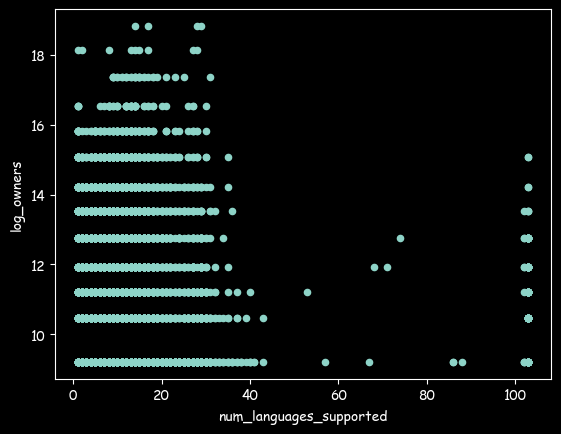

In [107]:
# Graph

df.plot.scatter(x='num_languages_supported', y='log_owners')
plt.rcParams['font.family'] = 'Comic Sans MS'



¿El primer analisis que podríamos es ver una correlación entre los lenguajes que soporta el juego y la cantidad de usuarios, acaso el tener más idiomas impacta en las ventas?

In [99]:
print(f"Languages vs Owners (Spearman): {df['num_languages_supported'].corr(df['log_owners'], method='spearman')}")

print(f"Languages vs Owners (kendall): {df['num_languages_supported'].corr(df['log_owners'], method='kendall')}")

Languages vs Owners (Spearman): 0.1966767757838673
Languages vs Owners (kendall): 0.16886459420059077


Podemos observar que las correlaciones son bastante bajas, por lo que podemos afirmar que simplemente por añadir más idiomas al azar a un juego no va a tener un impacto significativo en su cantidad de usuarios

Pero ahora, no es lo mismo traducir un juego a un idioma X que a un idioma muy hablado, en el siguiente analisis nos vamos a centrar en los 5 idiomas más usados en Steam.

- Ingles
- Chino
- Ruso
- Español
- Portugués

Source (https://store.steampowered.com/hwsurvey/)

Adicionalmente, por vamos a añadir japones.


In [100]:
df['supported_languages'] = df['supported_languages'].fillna('')

# Create columns for analysis

df['has_english'] = df['supported_languages'].apply(lambda x: 1 if 'english' in str(x).lower() else 0)
df['has_chinese'] = df['supported_languages'].apply(lambda x: 1 if 'chinese' in str(x).lower() else 0)
df['has_russian'] = df['supported_languages'].apply(lambda x: 1 if 'russian' in str(x).lower() else 0)
df['has_spanish'] = df['supported_languages'].apply(lambda x: 1 if 'spanish' in str(x).lower() else 0)
df['has_portuguese'] = df['supported_languages'].apply(lambda x: 1 if 'portuguese' in str(x).lower() else 0)

df['has_japanese'] = df['supported_languages'].apply(lambda x: 1 if 'japanese' in str(x).lower() else 0)

df['antiquity'] = df['release_date'].apply(lambda x: date.today().year - int(str(x).split(',')[1]) )

In [101]:
df_model = df.dropna(subset=['score', 'price', 'log_owners'])

X = df_model[['score', 'price', 'antiquity', 'has_chinese', 'has_russian', 'has_spanish', 'has_english', 'has_portuguese', 'has_japanese']]
X = sm.add_constant(X)

y = df_model['log_owners']

model = sm.OLS(y, X).fit()

print(model.summary())



                            OLS Regression Results                            
Dep. Variable:             log_owners   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     2181.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:20:18   Log-Likelihood:            -1.2643e+05
No. Observations:               82949   AIC:                         2.529e+05
Df Residuals:                   82939   BIC:                         2.530e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              8.5274      0.025    335.

In [102]:
# Results
lang_vars = {
    'has_chinese':    'Chino',
    'has_russian':    'Ruso',
    'has_spanish':    'Español',
    'has_english':    'Inglés',
    'has_portuguese': 'Portugués',
    'has_japanese':   'Japonés',
}

for var, label in lang_vars.items():
    impact = (math.exp(model.params[var]) - 1) * 100
    print(f"El {label} tiene un impacto del: {impact:.2f}% en la cantidad de usuarios")

El Chino tiene un impacto del: 29.63% en la cantidad de usuarios
El Ruso tiene un impacto del: 22.64% en la cantidad de usuarios
El Español tiene un impacto del: 41.16% en la cantidad de usuarios
El Inglés tiene un impacto del: -1.41% en la cantidad de usuarios
El Portugués tiene un impacto del: 9.94% en la cantidad de usuarios
El Japonés tiene un impacto del: 8.68% en la cantidad de usuarios


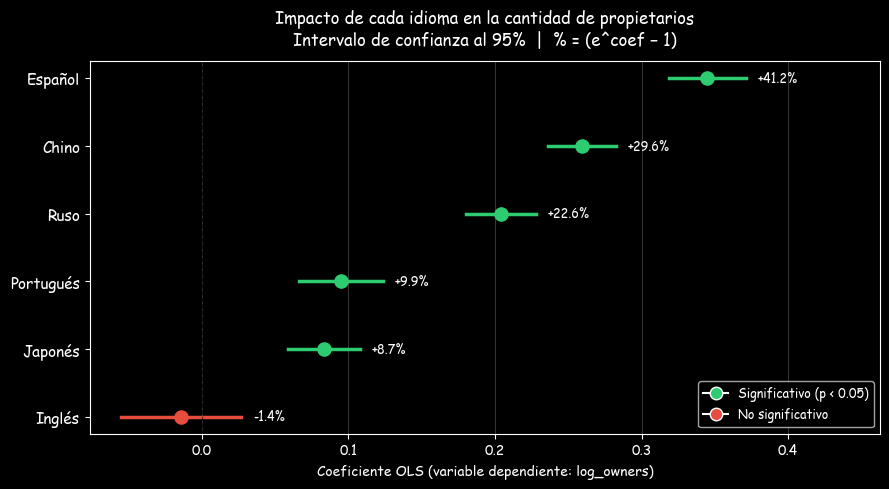

In [108]:
# Forest plot — coeficientes de idioma con intervalos de confianza al 95%
from matplotlib.lines import Line2D

conf_int = model.conf_int()
pvalues  = model.pvalues

coefs = pd.DataFrame({
    'language':   [lang_vars[v] for v in lang_vars],
    'coef':       [model.params[v] for v in lang_vars],
    'ci_low':     [conf_int.loc[v, 0] for v in lang_vars],
    'ci_high':    [conf_int.loc[v, 1] for v in lang_vars],
    'pvalue':     [pvalues[v] for v in lang_vars],
    'impact_pct': [(math.exp(model.params[v]) - 1) * 100 for v in lang_vars],
}).sort_values('coef', ascending=True).reset_index(drop=True)

colors = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in coefs['pvalue']]

fig, ax = plt.subplots(figsize=(9, 5))

for i, row in coefs.iterrows():
    ax.plot([row['ci_low'], row['ci_high']], [i, i], color=colors[i], linewidth=2.5)
    ax.scatter(row['coef'], i, color=colors[i], zorder=5, s=90)
    ax.text(row['ci_high'] + 0.008, i, f"{row['impact_pct']:+.1f}%", va='center', fontsize=9)

ax.axvline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.6)
ax.set_yticks(range(len(coefs)))
ax.set_yticklabels(coefs['language'], fontsize=11)
ax.set_xlabel('Coeficiente OLS (variable dependiente: log_owners)', fontsize=10)
ax.set_title(
    'Impacto de cada idioma en la cantidad de propietarios\n'
    'Intervalo de confianza al 95%  |  % = (e^coef − 1)',
    fontsize=12, pad=12
)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=9, label='Significativo (p < 0.05)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=9, label='No significativo'),
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)

xmin, xmax = ax.get_xlim()

ax.set_xlim(xmin, xmax + (xmax - xmin) * 0.15)

plt.rcParams['font.family'] = 'Comic Sans MS'
plt.tight_layout()
plt.show()

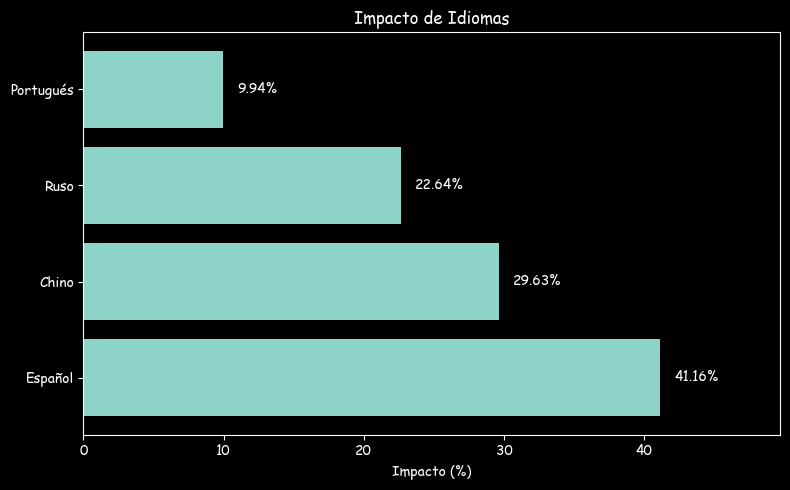

In [106]:
import matplotlib.pyplot as plt

languages = ["Español", "Chino", "Ruso", "Portugués"]
values = [41.16, 29.63, 22.64, 9.94]

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.barh(languages, values)

ax.set_xlabel("Impacto (%)")
ax.set_title("Impacto de Idiomas")

for i, v in enumerate(values):
    ax.text(v + 1, i, f"{v:.2f}%", va='center')

plt.rcParams['font.family'] = 'Comic Sans MS'


xmin, xmax = ax.get_xlim()

ax.set_xlim(xmin, xmax + (xmax - xmin) * 0.15)

plt.tight_layout()
plt.show()